In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random


In [4]:
df= pd.read_csv("Data/Data.csv", sep=";")

In [5]:
df.head()

,Date,China,USA,Eurozone
0,31.03.1996,10.9,2.6,1.2
1,30.06.1996,9.4,4.0,1.5
2,30.09.1996,9.2,4.1,1.8
3,31.12.1996,10.3,4.4,1.9
4,31.03.1997,10.1,4.3,2.0


In [19]:
float(df["China"].mean())

8.963541666666668

*Since the time series has a mean different from 0, we should use the model:*
- y_t = a*y_t-1 + b + epsilon_t


instead of :
- y_t = a*y_t-1 + epsilon_t

We can start by defining the gradient function that compute:
∂aJ(a,b) and ∂bJ(a,b)

we recall that J(a,b) = 1/2n ∑ (y_i -(ax_i + b))^2

In [164]:
def gradient(a,b,x,y):
    n = len(x)

    da = -1/n * np.sum(x*(y-(a*x + b)))
    db = -1/n * np.sum(y-(a*x + b))
    return da, db

Let's implement the gradient descent function to predict the AR(1) model :
Since I don't know what is the optimal learning rate I'm gonna try 0.1, 0.01, 0.001.

if it diverges I take a lower rate
If it converge slowly I increase it

rk : here the loss function is quadratic, so convex so the gradient descent converges necessarily to the global minimum

Question : Can we assume that the time series is stationary ?

If yes : |a| < 1

Here I don't know if it is stationary so I take a real following a gaussian distribution

In [200]:
def gradient_descent(x,y,eta=0.01, n_iter=100000):
    a= np.random.normal(0,1)
    b = np.random.normal(0,1)

    for _ in range(n_iter):
        da, db = gradient(a,b,x,y)
        a -= eta*da
        b -= eta*db

    return a,b

We can now fit the gradient descent to the AR(1) model :

In [201]:
china = df["China"].to_numpy()

In [202]:
def fit_ar1_gd(y):
    x = y[:-1] #x : y_t-1
    y_t = y[1:]

    return gradient_descent(x,y_t)


In [203]:
a_hat, b_hat = fit_ar1_gd(china)

In [204]:
a_hat, b_hat

(np.float64(0.8880703236200526), np.float64(0.955199036491206))

Rk1 : with eta=0.1 , I get the following error : RuntimeWarning: invalid value encountered in scalar subtract
  a -= eta*da


but it works with eta= 0.01

Rk2: 10_000 iterations is already okay, but I set 100_000 iterations to be very precise

We can now check if the model's prediction is close to the actual values

MSE = 1/n ∑ (Y_i - Y_i^hat)^2

In [216]:
y_fit = a_hat*china[:-1] + b_hat
residuals = china[1:] - y_fit
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)
y_t_variance = np.var(china[1:])

R2 = 1 - mse/y_t_variance

In [217]:
mse, rmse, y_t_variance, R2

(np.float64(0.9517738217722999),
 np.float64(0.975588961485471),
 np.float64(4.303926869806094),
 np.float64(0.7788592021743204))

We obtained an RMSE of 0.97, which means that the typical prediction error is about 1. This is relatively small compared to the variance of the series of 4.3, suggesting that the model fits the data reasonably well.

We obtained a R^2 of 0.77, which means that 77% of the variance of y_t is explained by the model

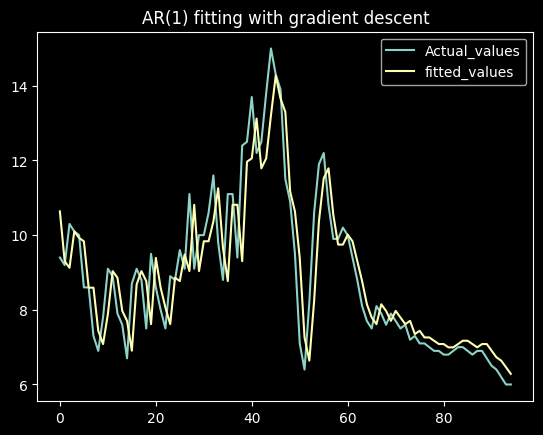

In [220]:
plt.figure()
plt.plot(china[1:],label="Actual_values")
plt.plot(y_fit, label="fitted_values")
plt.legend()
plt.title("AR(1) fitting with gradient descent")
plt.show()

Both lines almost overlap, so we can conclude that the model fits well

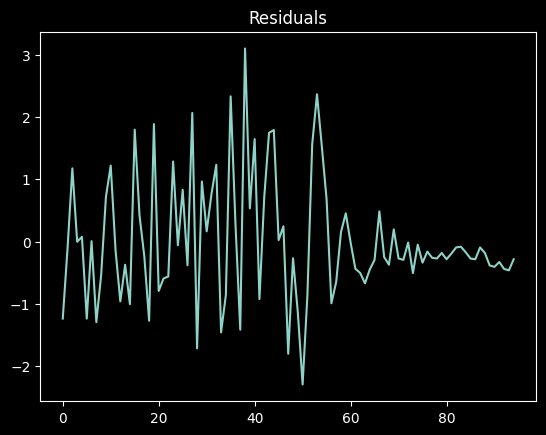

In [222]:
plt.figure()
plt.plot(residuals)
plt.title("Residuals")
plt.show()

Residuals look like noise from observation 1 to 55 (from 1996 to 2009) and from observation 55 to 96 (from 2009 to 2019), but we can observe a change of regime between them. So we have heteroscedasticity.

Can we conclude that there is a regime change in the economy between pre-2009 and post-2009 based on the observation of noise?